In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *

import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from itertools import permutations, compress, product



%load_ext autoreload 
%autoreload 2
%matplotlib widget

# lets try on 16 good lasers, 

In [2]:
pre=100
post=100
session_path = '../data/vgat2_06062023'
session = MPOptoClass(session_path, post=post)

love


In [3]:
og_psth_bounds = session.get_highlaser_bounds()
og_psth_ctrl_bounds = session.laser['ctrl_bounds']
og_psth_ctrl_bounds[:,0] = og_psth_ctrl_bounds[:,0] - pre
og_psth_bounds[:,0] = og_psth_bounds[:,0] - pre

omitCtrlBounds = omitBoundInBounds(session.climbing_bounds, og_psth_ctrl_bounds)
psth_newbounds, climbing_duration = reBoundInBounds(omitCtrlBounds, og_psth_bounds)


In [4]:
num_lasers = np.arange(og_psth_bounds.shape[0])

big_laser_true = []
big_laser_predic = []

big_ctrl_true = []
big_ctrl_predic = []


for held_out_num in tqdm(num_lasers):
    train_psth_bounds = copy.deepcopy(psth_newbounds)
    train_psth_bounds = np.delete(train_psth_bounds, held_out_num, axis=0)
    test_psth_bounds = psth_newbounds[held_out_num, :]
    test_psth_bounds = test_psth_bounds[None, :]
    
    
    trainBounds = omitBoundInBounds(omitCtrlBounds, test_psth_bounds)
    train_psth_bounds, duration = reBoundInBounds(trainBounds, train_psth_bounds)
    laser_logical = bounds2Logical(train_psth_bounds, duration=duration)
    laser_logical_trials = unstitchSeams(laser_logical, getSeamsFromBounds(trainBounds, binsize=1))
    
    sw_list = []
    for trial in laser_logical_trials:
        temp = bin_timeseries(trial, binsize=10)
        sw_list.append(format_single_array(temp))
    sw = (np.hstack(sw_list))[:-1]

    sw = (sw*4)+1
    
    print(sw.shape)
    
    (all_nlags_PCA, all_cut_PCA), PCA_Objs = session.format_nlags_PCA(bounds=trainBounds, binsize=10, nlags=10)
    h = weighted_parameter_fit(all_nlags_PCA[:40000,:], all_cut_PCA[:40000,:], c=50000, sw=sw[:40000])
    
    temp_bounds = og_psth_bounds[held_out_num,:]
    temp_bounds = temp_bounds[None,:]
    
    laser_input, laser_true = session.transformat(PCA_Objs, bounds=temp_bounds)
    ctrl_input, ctrl_true = session.transformat(PCA_Objs, bounds=og_psth_ctrl_bounds)
    
    big_laser_true.append(laser_true)
    big_laser_predic.append(test_wiener_filter(laser_input, h))

    big_ctrl_true.append(ctrl_true)
    big_ctrl_predic.append(test_wiener_filter(ctrl_input, h))
    
    
    
big_laser_true = np.vstack(big_laser_true)
big_laser_predic = np.vstack(big_laser_predic)
big_ctrl_true = np.vstack(big_ctrl_true)
big_ctrl_predic = np.vstack(big_ctrl_predic)

big_laser_true = big_laser_true[:, session.num_CFA:]
big_laser_predic = big_laser_predic[:, session.num_CFA:]
big_ctrl_true = big_ctrl_true[:, session.num_CFA:]
big_ctrl_predic = big_ctrl_predic[:, session.num_CFA:]

  0%|                                                                                                                                                                | 0/17 [00:00<?, ?it/s]

(55671,)


  6%|████████▉                                                                                                                                               | 1/17 [01:07<18:03, 67.74s/it]

(55701,)


 12%|█████████████████▉                                                                                                                                      | 2/17 [02:15<16:57, 67.84s/it]

...

 88%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                 | 15/17 [16:56<02:15, 67.70s/it]

(55701,)


 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████         | 16/17 [18:03<01:07, 67.67s/it]

(55701,)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [19:11<00:00, 67.72s/it]


In [9]:
laser_r2 = weighted_r2(big_laser_true, big_laser_predic)
ctrl_r2 = weighted_r2(big_ctrl_true, big_ctrl_predic)

print(f'laser: {laser_r2}')
print(f'ctrl: {ctrl_r2}')

laser: 0.04833358873901974
ctrl: 0.0744590979950157


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


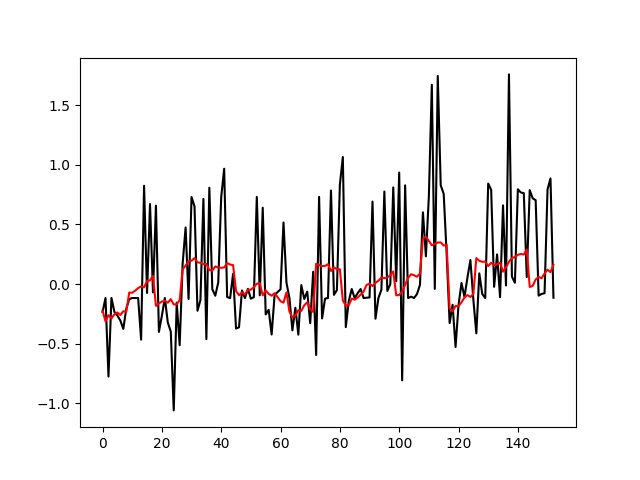

In [12]:
fig, ax = plt.subplots()
ax.plot(big_laser_true[:,1], c='black')
ax.plot(big_laser_predic[:,1], c='red')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


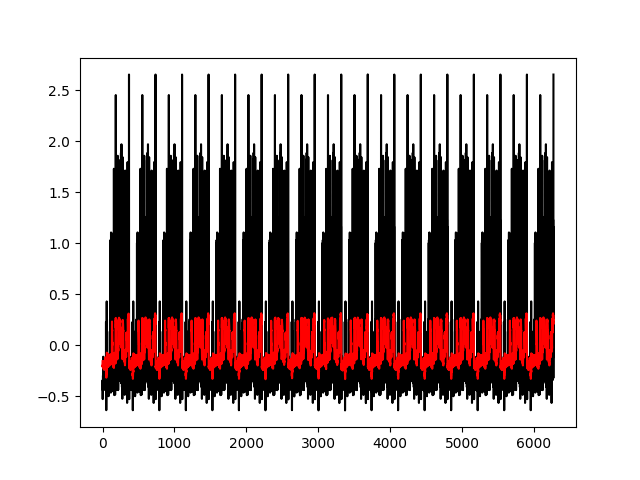

In [14]:
fig1, ax1 = plt.subplots()
ax1.plot(big_ctrl_true[:,0], c='black')
ax1.plot(big_ctrl_predic[:,0], c='red')